# Assignment 8

First we need to import the different libraries needed in the project.

In [43]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import json
import cv2
import matplotlib.pyplot as plt

print("Successfully imported all dependencies!")

Successfully imported all dependencies!


Now we define the function to be used.

In [44]:
def extract_joint_nodes(video_path: str, output_json_path: str, model_path: str='../data/pose_landmarker_full.task'):
	base_options = python.BaseOptions(model_path)
	options = vision.PoseLandmarkerOptions(
		base_options=base_options,
		running_mode=vision.RunningMode.IMAGE,
		num_poses=1,
		min_pose_detection_confidence=0.5,
		min_tracking_confidence=0.5,
		output_segmentation_masks=False
	)

	cap = cv2.VideoCapture(video_path)
	frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
	frame_num = 0

	all_landmarks_data = {}

	with vision.PoseLandmarker.create_from_options(options) as landmarker:
		while cap.isOpened():

			success, frame = cap.read()
			if success:
				rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
				mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

				result = landmarker.detect(mp_image)

				frame_data = {
					"landmarks": []
				}
				if result.pose_landmarks:
					for detection in result.pose_landmarks:
						frame_data["landmarks"] = ([{"id":idx, "x":detection[idx].x, "y":detection[idx].y} for idx in range(len(detection))])
				
				all_landmarks_data[frame_num] = frame_data

				frame_num += 1
			
			else:
				break

	cap.release()

	return all_landmarks_data


And now we demonstrate that the function works as intended!

{'landmarks': [{'id': 0, 'x': 0.5258128046989441, 'y': 0.13974057137966156}, {'id': 1, 'x': 0.5421971678733826, 'y': 0.12944376468658447}, {'id': 2, 'x': 0.5496679544448853, 'y': 0.1299150586128235}, {'id': 3, 'x': 0.5557958483695984, 'y': 0.13025370240211487}, {'id': 4, 'x': 0.5148656964302063, 'y': 0.129123717546463}, {'id': 5, 'x': 0.5056922435760498, 'y': 0.12933465838432312}, {'id': 6, 'x': 0.4980252981185913, 'y': 0.12962448596954346}, {'id': 7, 'x': 0.5703912973403931, 'y': 0.1356264054775238}, {'id': 8, 'x': 0.4883512854576111, 'y': 0.13626697659492493}, {'id': 9, 'x': 0.5437451004981995, 'y': 0.15306757390499115}, {'id': 10, 'x': 0.510412335395813, 'y': 0.15276627242565155}, {'id': 11, 'x': 0.635649561882019, 'y': 0.21049651503562927}, {'id': 12, 'x': 0.4337064027786255, 'y': 0.2085634022951126}, {'id': 13, 'x': 0.6783648133277893, 'y': 0.23848816752433777}, {'id': 14, 'x': 0.35900866985321045, 'y': 0.22877037525177002}, {'id': 15, 'x': 0.7167731523513794, 'y': 0.2112087160348

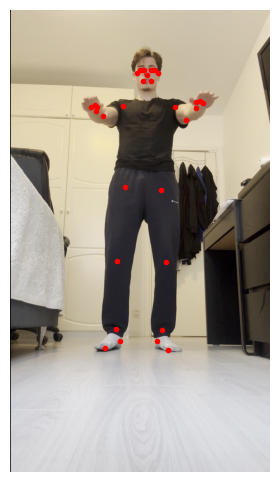

In [76]:
def display_frame(image, node_data):

	height, width, _ = image.shape
	plt.figure(figsize=[4,6])
	plt.imshow(image)

	x = []
	y = []
	
	for node in node_data["landmarks"]:
		x += [node["x"] * width]
		y += [node["y"] * height]
	
	plt.plot(x, y, "r.")
	plt.axis("off")
	plt.show()

video_path = "../../EnisProject/data/test_squat.mp4"
output_json_path = "../data/test_squat_landmarks.json"
model_path = '../data/pose_landmarker_full.task'

nodes = extract_joint_nodes(video_path, output_json_path)

print(nodes[0])

cap = cv2.VideoCapture(video_path)
success, image = cap.read()
if success:
	display_frame(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), nodes[0])
cap.release()